# Training 3 different RNNs

In this notebook I will train 3 different RNNs, one simple RNN, one LSTM and one GRU.

In [1]:
import pandas as pd
import numpy as np
import os
import augumentations as aug
import data_functions as dfunc
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

folder_path = "../../MainProject/data/mediapipe_not_trimmed_world"
score_path = "../../MainProject/data/video_scores.csv"

device = torch.device("cpu")

random_state = 42

## Data Creation

We begin by creating the data we need as well as augumenting it by mirroring and rotating the node network.

In [2]:
train_data, test_data, train_y, test_y = dfunc.load_folder_with_split(
    folder_path=folder_path,
    target_path=score_path,
    test_size=0.2,
    random_state=random_state,
    select_rows=True,
    num_rows=30)

# Which axis to flip (x, y, z)
mirror_setups = [
    [False, False, False],
    [True, False, False],
    [False, True, False],
    [False, False, True]]

# First and last rotate nothing
rotations = np.linspace(0, 2*np.pi, 5)[1:-1]

X_train = dfunc.augument_data(train_data, mirror_axis=mirror_setups, rotations=rotations)
X_test = dfunc.augument_data(test_data, mirror_axis=[[False, False, False]], rotations=[0])
Y_train = torch.tensor(train_y, dtype=torch.float32).reshape(-1, 1)
Y_test = torch.tensor(test_y, dtype=torch.float32).reshape(-1, 1)

# Extend the labels to add target cariables for the augumented data
factor = len(mirror_setups) * len(rotations)
Y_train = dfunc.extend_tensor(Y_train, factor)

print(f"Number of training samples: {X_train.shape[0]}")
print(f"Number of test samples: {X_test.shape[0]}")

Number of training samples: 1680
Number of test samples: 35


## Initialize the Models

In [3]:
import RNN_models
import RNN_functions
import torch.nn as nn
import torch.optim as optim
from torchinfo import summary

### Simple

In [4]:
models = []
models_stats = []
models_metadata = []

params_RNN = {
    "model_type": RNN_models.SimpleRNNModel,
    "classifier": False,
    "input_size": X_train.shape[2],
    "hidden_size": 32,
    "depth": 5,
    "num_of_classification_labels": 1,
    "lr": 0.0001,
    "loss_func": nn.MSELoss,
    "optimizer": optim.Adam,
    "patience": 3,
    "epochs": 100}

RNN, RNN_stats = RNN_functions.train_model(params=params_RNN, train_data=X_train, train_labels=Y_train, device=device, classifier=params_RNN["classifier"])
models.append(RNN)
models_stats.append(RNN_stats)
models_metadata.append(params_RNN)

print(f"The final loss achieved: {RNN_stats["final_stats"]["loss_history"][-1]}")
model_summary = summary(RNN)
print(model_summary)


Performing 5-fold cross-validation...

--- Fold 1/5 ---
Fold 1 training with 100 epochs
Start            Finished
v                       v
#########################

--- Fold 2/5 ---
Fold 2 training with 100 epochs
Start            Finished
v                       v
##############X

Early stopping at epoch 56


--- Fold 3/5 ---
Fold 3 training with 100 epochs
Start            Finished
v                       v
#########################

--- Fold 4/5 ---
Fold 4 training with 100 epochs
Start            Finished
v                       v
###################X

Early stopping at epoch 74


--- Fold 5/5 ---
Fold 5 training with 100 epochs
Start            Finished
v                       v
#########################

Cross-Validation Results:
  Mean validation accuracy: 6.9818 ± 3.9461
  Mean best accuracy: 6.9818
  Mean epochs trained: 86.0

--- Training final model on all data ---
Final training with 100 epochs
Start            Finished
v                       v
#########################

### LSTM

In [5]:
params_LSTM = {
    "model_type": RNN_models.LSTMModel,
    "classifier": False,
    "input_size": X_train.shape[2],
    "hidden_size": 32,
    "depth": 5,
    "num_of_classification_labels": 1,
    "lr": 0.0001,
    "loss_func": nn.MSELoss,
    "optimizer": optim.Adam,
    "patience": 3,
    "epochs": 100}

LSTM, LSTM_stats = RNN_functions.train_model(params=params_LSTM, train_data=X_train, train_labels=Y_train, device=device, classifier=params_LSTM["classifier"])
models.append(LSTM)
models_stats.append(LSTM_stats)
models_metadata.append(params_LSTM)

print(f"The final loss achieved: {LSTM_stats["final_stats"]["loss_history"][-1]}")
model_summary = summary(LSTM)
print(model_summary)


Performing 5-fold cross-validation...

--- Fold 1/5 ---
Fold 1 training with 100 epochs
Start            Finished
v                       v
#########################

--- Fold 2/5 ---
Fold 2 training with 100 epochs
Start            Finished
v                       v
#########################

--- Fold 3/5 ---
Fold 3 training with 100 epochs
Start            Finished
v                       v
###X

Early stopping at epoch 13


--- Fold 4/5 ---
Fold 4 training with 100 epochs
Start            Finished
v                       v
#########################

--- Fold 5/5 ---
Fold 5 training with 100 epochs
Start            Finished
v                       v
#########################

Cross-Validation Results:
  Mean validation accuracy: 6.6909 ± 3.6335
  Mean best accuracy: 6.9818
  Mean epochs trained: 82.6

--- Training final model on all data ---
Final training with 100 epochs
Start            Finished
v                       v
#########################
The final loss achieved: 0.0007208

### GRU

In [6]:
params_GRU = {
    "model_type": RNN_models.GRUModel,
    "classifier": False,
    "input_size": X_train.shape[2],
    "hidden_size": 32,
    "depth": 5,
    "num_of_classification_labels": 1,
    "lr": 0.0001,
    "loss_func": nn.MSELoss,
    "optimizer": optim.Adam,
    "patience": 3,
    "epochs": 100}

GRU, GRU_stats = RNN_functions.train_model(params=params_GRU, train_data=X_train, train_labels=Y_train, device=device, classifier=params_GRU["classifier"])
models.append(GRU)
models_stats.append(GRU_stats)
models_metadata.append(params_GRU)

print(f"The final loss achieved: {GRU_stats["final_stats"]["loss_history"][-1]}")
model_summary = summary(GRU)
print(model_summary)


Performing 5-fold cross-validation...

--- Fold 1/5 ---
Fold 1 training with 100 epochs
Start            Finished
v                       v
#########################

--- Fold 2/5 ---
Fold 2 training with 100 epochs
Start            Finished
v                       v
#######################X

Early stopping at epoch 91


--- Fold 3/5 ---
Fold 3 training with 100 epochs
Start            Finished
v                       v
#########################

--- Fold 4/5 ---
Fold 4 training with 100 epochs
Start            Finished
v                       v
#########################

--- Fold 5/5 ---
Fold 5 training with 100 epochs
Start            Finished
v                       v
#########################

Cross-Validation Results:
  Mean validation accuracy: 6.6909 ± 4.0727
  Mean best accuracy: 6.9818
  Mean epochs trained: 98.2

--- Training final model on all data ---
Final training with 100 epochs
Start            Finished
v                       v
#########################
The final loss

## Visualize Training

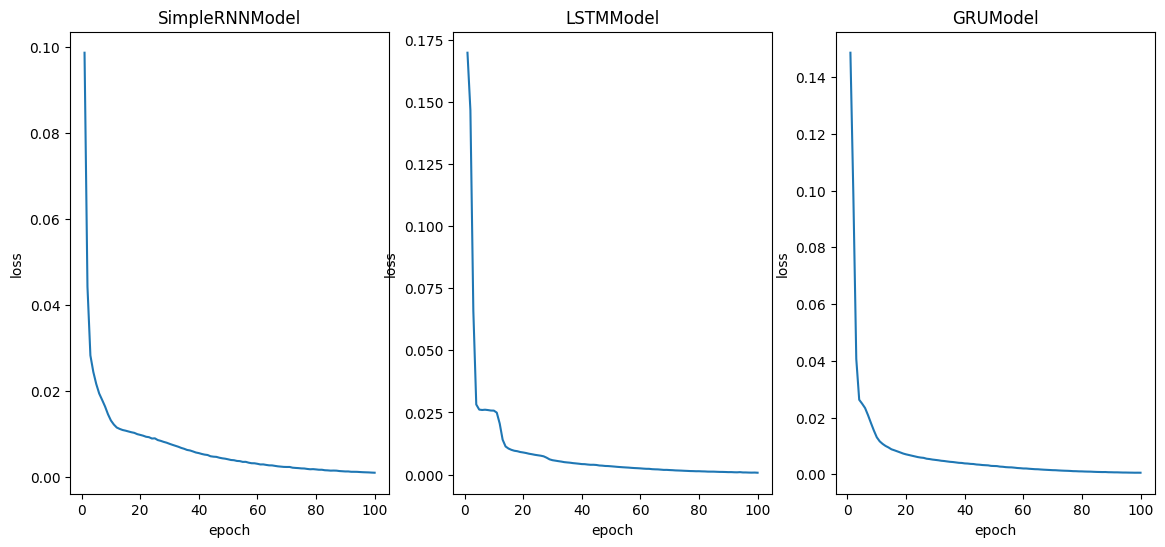

In [7]:
from matplotlib import pyplot as plt

fig, axs = plt.subplots(1, len(models), figsize=[14, 6])

for i, stats in enumerate(models_stats):
    if len(models) > 1:
        ax = axs[i]
    else:
        ax = axs
    ax.set_title(models[i].to_string())
    ax.plot([i for i in range(1, len(stats["final_stats"]["loss_history"]) + 1)], stats["final_stats"]["loss_history"])
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")

plt.show()

## Evaluate Models


Model: SimpleRNNModel
MSE:  0.6206
RMSE: 0.7878
MAE:  0.6172
R²:   0.2530


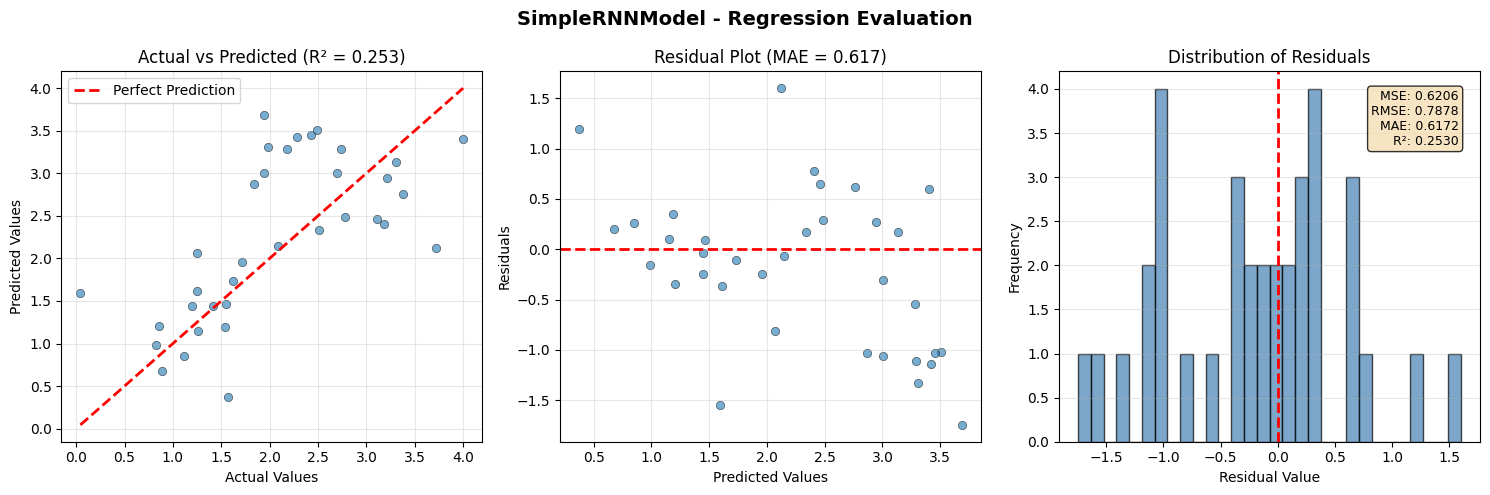


Model: LSTMModel
MSE:  0.3369
RMSE: 0.5804
MAE:  0.4289
R²:   0.5945


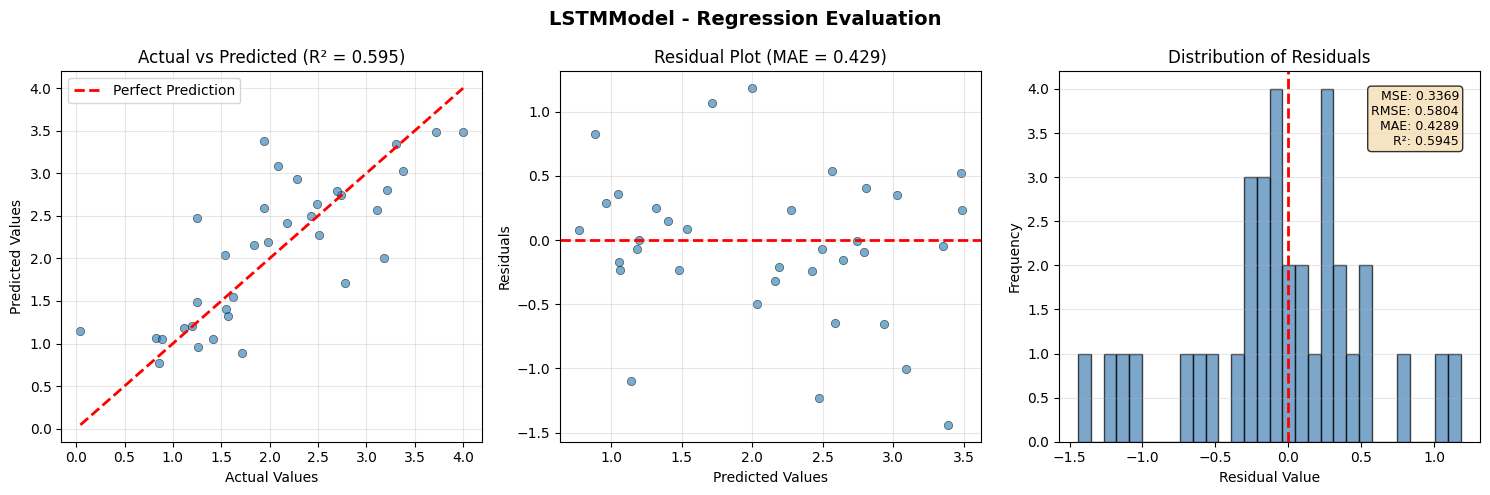


Model: GRUModel
MSE:  0.6085
RMSE: 0.7800
MAE:  0.6659
R²:   0.2677


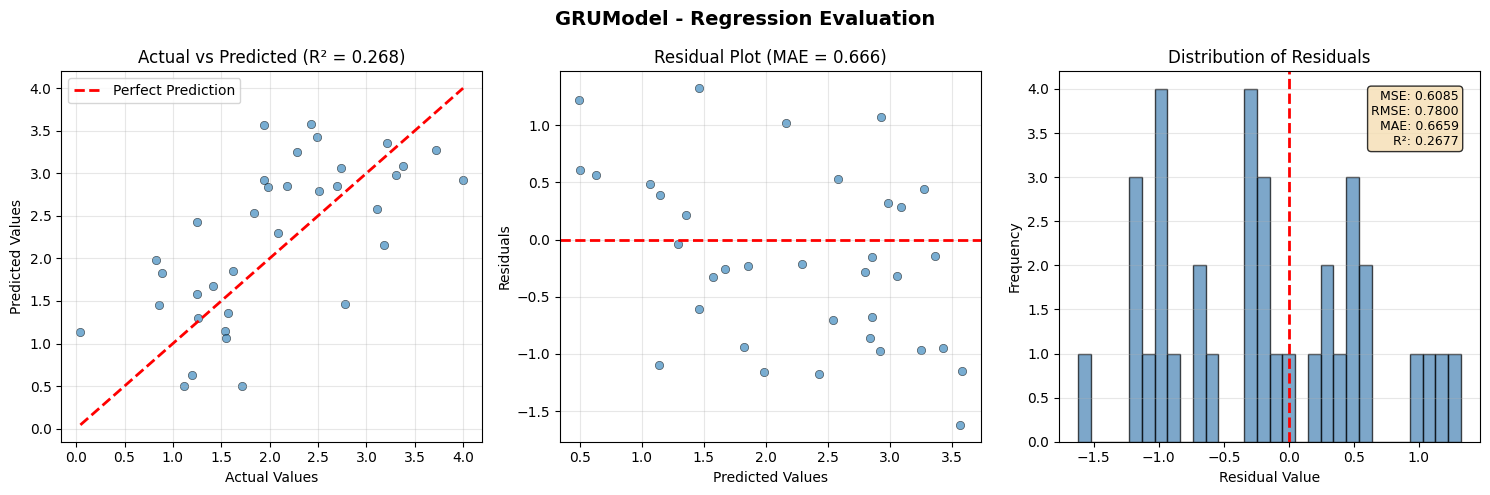

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

for i, model in enumerate(models):
    model.eval()
    with torch.no_grad():
        predictions = model(X_test).cpu().numpy()
        
        # Calculate metrics
        mse = mean_squared_error(Y_test, predictions)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(Y_test, predictions)
        r2 = r2_score(Y_test, predictions)
        
        # Print metrics
        print(f"\n{'='*50}")
        print(f"Model: {models[i].to_string()}")
        print(f"{'='*50}")
        print(f"MSE:  {mse:.4f}")
        print(f"RMSE: {rmse:.4f}")
        print(f"MAE:  {mae:.4f}")
        print(f"R²:   {r2:.4f}")
        
        # Create visualization
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        fig.suptitle(f"{models[i].to_string() if hasattr(models[i], 'to_string') else type(model).__name__} - Regression Evaluation", 
                     fontsize=14, fontweight='bold')
        
        # Plot 1: Actual vs Predicted
        axes[0].scatter(Y_test, predictions, alpha=0.6, edgecolors='k', linewidth=0.5)
        axes[0].plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', lw=2, label='Perfect Prediction')
        axes[0].set_xlabel('Actual Values')
        axes[0].set_ylabel('Predicted Values')
        axes[0].set_title(f'Actual vs Predicted (R² = {r2:.3f})')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Plot 2: Residuals
        residuals = Y_test - predictions
        axes[1].scatter(predictions, residuals, alpha=0.6, edgecolors='k', linewidth=0.5)
        axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
        axes[1].set_xlabel('Predicted Values')
        axes[1].set_ylabel('Residuals')
        axes[1].set_title(f'Residual Plot (MAE = {mae:.3f})')
        axes[1].grid(True, alpha=0.3)
        
        # Plot 3: Distribution of errors
        axes[2].hist(residuals, bins=30, alpha=0.7, edgecolor='black', color='steelblue')
        axes[2].axvline(x=0, color='r', linestyle='--', lw=2)
        axes[2].set_xlabel('Residual Value')
        axes[2].set_ylabel('Frequency')
        axes[2].set_title('Distribution of Residuals')
        axes[2].grid(True, alpha=0.3, axis='y')
        
        # Add text box with metrics
        metrics_text = f'MSE: {mse:.4f}\nRMSE: {rmse:.4f}\nMAE: {mae:.4f}\nR²: {r2:.4f}'
        axes[2].text(0.95, 0.95, metrics_text, transform=axes[2].transAxes,
                    fontsize=9, verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        
        plt.tight_layout()
        plt.show()

## Save Models

In [9]:
for i, model in enumerate(models):
    file_name = model.to_string() + "_scoring_checkpoint.pth"
    checkpoint = {
        "model_config": models_metadata[i],
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": models_stats[i]["final_stats"]["optimizer"].state_dict(),
        "model_statistics": models_stats[i]
    }
    torch.save(checkpoint, f"../models/scoring_RNN_models/{file_name}")
    print(f"Saved model {model.to_string()} to {file_name}")

Saved model SimpleRNNModel to SimpleRNNModel_scoring_checkpoint.pth
Saved model LSTMModel to LSTMModel_scoring_checkpoint.pth
Saved model GRUModel to GRUModel_scoring_checkpoint.pth
